# Exploratory Data Analysis (EDA)

## Objective

This notebook performs a comprehensive exploratory data analysis on the
IBM Telco Customer Churn dataset.

Goals:

- Understand customer demographics
- Study churn behaviour
- Explore numerical and categorical variables
- Identify feature relationships
- Detect outliers
- Generate business insights

The outputs from this notebook will guide feature engineering and
machine learning model development.

In [1]:
# ============================================================
# Exploratory Data Analysis
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


# plotting style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

In [2]:
import sys

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config.paths import (
    REPORTS_FIGURES_DIR,
    ARTIFACTS_DIR,
    INTERIM_DATA_DIR
)

FIGURE_DIR = REPORTS_FIGURES_DIR

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
from src.data.data_loader import load_ml_dataset
from src.config.paths import INTERIM_DATA_DIR

ML_INTERIM_DATA = INTERIM_DATA_DIR / "ml_dataset_interim.csv"

df = load_ml_dataset(ML_INTERIM_DATA)

# Coerce TotalCharges to numeric and fill NaNs with 0.0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0.0)

# Drop duplicate records ignoring customerID
df.drop_duplicates(subset=df.columns.drop("customerID"), inplace=True)

print(df.shape)
display(df.head())

(7021, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("=" * 60)
print("Dataset Information")
print("=" * 60)

display(df.info())

display(df.describe())

display(df.describe(include="object"))

Dataset Information
<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7021 non-null   object 
 1   gender            7021 non-null   object 
 2   SeniorCitizen     7021 non-null   int64  
 3   Partner           7021 non-null   object 
 4   Dependents        7021 non-null   object 
 5   tenure            7021 non-null   int64  
 6   PhoneService      7021 non-null   object 
 7   MultipleLines     7021 non-null   object 
 8   InternetService   7021 non-null   object 
 9   OnlineSecurity    7021 non-null   object 
 10  OnlineBackup      7021 non-null   object 
 11  DeviceProtection  7021 non-null   object 
 12  TechSupport       7021 non-null   object 
 13  StreamingTV       7021 non-null   object 
 14  StreamingMovies   7021 non-null   object 
 15  Contract          7021 non-null   object 
 16  PaperlessBilling  7021 non-

None

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7021.000000,7021.000000,7021.000000,7021.000000
mean,0.162512,32.469449,64.851894,2286.765026
std,0.368947,24.534965,30.069001,2266.855057
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.750000,403.350000
50%,0.000000,29.000000,70.400000,1400.550000
75%,0.000000,55.000000,89.900000,3801.700000
max,1.000000,72.000000,118.750000,8684.800000


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7021,7021,7021,7021,7021,7021,7021,7021,7021,7021,7021,7021,7021,7021,7021,7021,7021
unique,7021,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3541,3619,4911,6339,3368,3090,3490,3080,3087,3465,2802,2777,3853,4161,2359,5164


In [5]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .to_frame("Missing Values")
)

missing["Percentage"] = (
    missing["Missing Values"] / len(df)
) * 100

missing

,Missing Values,Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


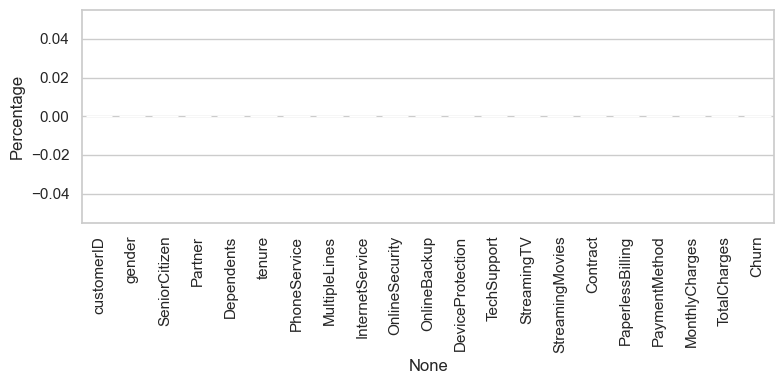

In [6]:
plt.figure(figsize=(8,4))

sns.barplot(
    x=missing.index,
    y=missing["Percentage"]
)

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(FIGURE_DIR / "missing_values.png")

plt.show()

In [7]:
# ============================================================
# Dataset Snapshot
# ============================================================

print("=" * 70)
print("DATASET SNAPSHOT")
print("=" * 70)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

display(df.head())

display(df.sample(5, random_state=42))

DATASET SNAPSHOT
Rows    : 7021
Columns : 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3918,6319-IEJWJ,Male,0,Yes,Yes,20,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,90.20,1776.55,Yes
2467,6559-RAKOZ,Male,0,Yes,Yes,49,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,One year,Yes,Electronic check,97.95,4917.90,No
2885,7923-IYJWY,Male,1,No,No,67,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),116.10,7839.85,No
3770,5821-MMEIL,Female,0,Yes,No,57,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.90,1115.60,No
3753,1816-FLZDK,Male,0,No,No,1,No,No phone service,DSL,No,No,No,Yes,No,No,Month-to-month,No,Mailed check,29.15,29.15,No


In [8]:
# ============================================================
# Missing Value Analysis
# ============================================================

missing_df = (
    df.isnull()
      .sum()
      .reset_index()
)

missing_df.columns = ["Feature", "Missing Values"]

missing_df["Percentage (%)"] = (
    missing_df["Missing Values"] / len(df) * 100
).round(2)

display(missing_df.sort_values("Missing Values", ascending=False))

,Feature,Missing Values,Percentage (%)
0,customerID,0,0.0
1,gender,0,0.0
2,SeniorCitizen,0,0.0
3,Partner,0,0.0
4,Dependents,0,0.0
5,tenure,0,0.0
6,PhoneService,0,0.0
7,MultipleLines,0,0.0
8,InternetService,0,0.0
9,OnlineSecurity,0,0.0


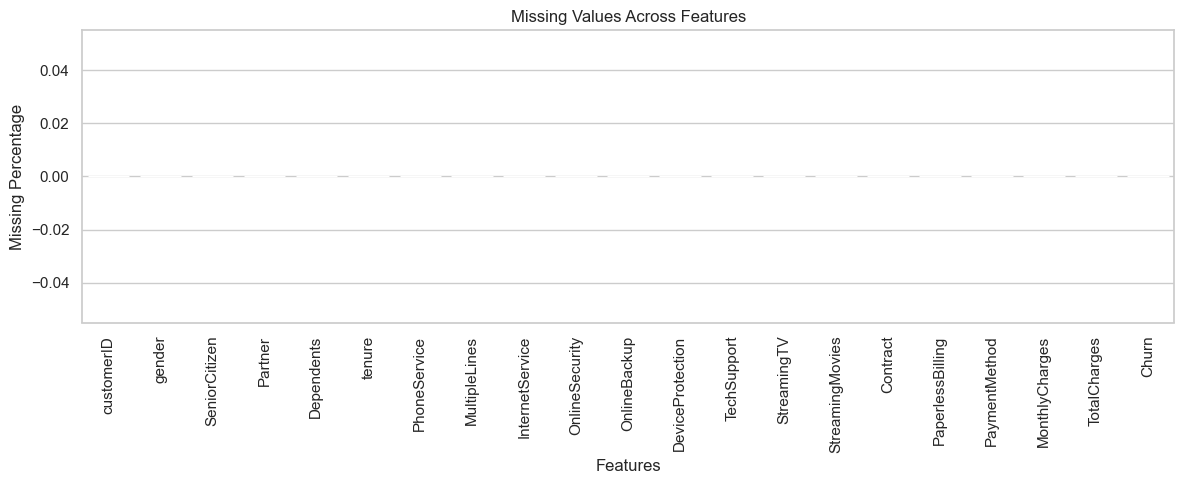

In [9]:
# ============================================================
# Missing Value Visualization
# ============================================================

plt.figure(figsize=(12,5))

sns.barplot(
    data=missing_df,
    x="Feature",
    y="Percentage (%)",
    color="steelblue"
)

plt.xticks(rotation=90)
plt.ylabel("Missing Percentage")
plt.xlabel("Features")
plt.title("Missing Values Across Features")

plt.tight_layout()

plt.savefig(FIGURE_DIR / "missing_values.png", dpi=300)

plt.show()

In [10]:
# ============================================================
# Missing Value Insights
# ============================================================

total_missing = df.isnull().sum().sum()

print("=" * 70)
print("BUSINESS INSIGHTS")
print("=" * 70)

if total_missing == 0:
    print("No missing values found in the dataset.")
    print("✓ Dataset is complete and suitable for downstream analysis.")
else:
    print(f"Total Missing Values : {total_missing}")

BUSINESS INSIGHTS
No missing values found in the dataset.
✓ Dataset is complete and suitable for downstream analysis.


In [11]:
# ============================================================
# Target Variable Analysis
# ============================================================

target_counts = df["Churn"].value_counts()

target_percentage = (
    df["Churn"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage (%)": target_percentage
})

display(target_summary)

,Count,Percentage (%)
Churn,,
No,5164,73.55
Yes,1857,26.45


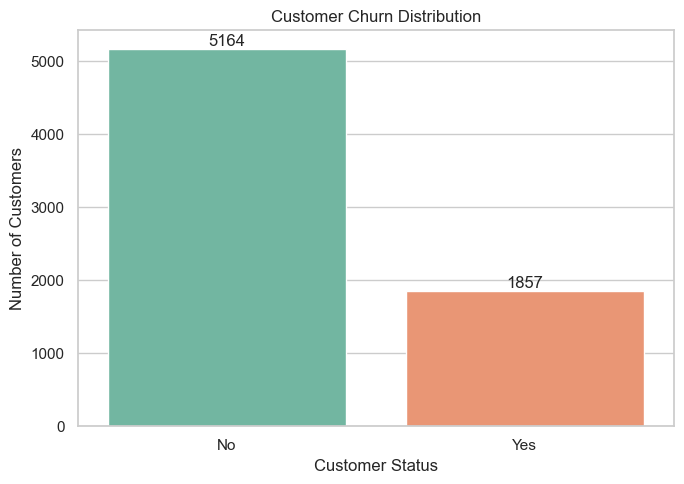

In [12]:
# ============================================================
# Customer Churn Distribution
# ============================================================

plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Churn",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "churn_distribution.png",
    dpi=300
)

plt.show()

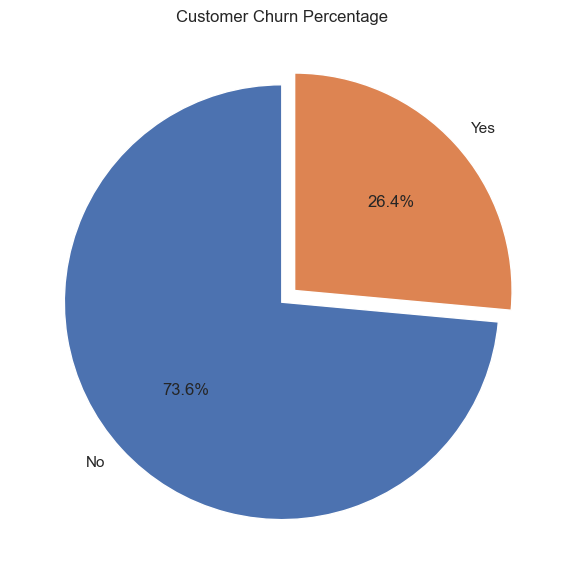

In [13]:
# ============================================================
# Churn Percentage
# ============================================================

plt.figure(figsize=(6,6))

plt.pie(
    target_counts,
    labels=target_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0,0.08)
)

plt.title("Customer Churn Percentage")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "churn_pie_chart.png",
    dpi=300
)

plt.show()

In [14]:
# ============================================================
# Business Insights - Target Variable
# ============================================================

print("=" * 70)
print("BUSINESS INSIGHTS")
print("=" * 70)

print(f"Total Customers : {len(df)}")
print(f"Customers Stayed : {target_counts['No']}")
print(f"Customers Churned : {target_counts['Yes']}")

print(f"\nOverall Churn Rate : {target_percentage['Yes']:.2f}%")

if target_percentage["Yes"] < 30:
    print("\nObservation:")
    print("- Approximately one out of every four customers has churned.")
    print("- The dataset exhibits a moderate class imbalance.")
    print("- Evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC will be more informative than accuracy alone.")

BUSINESS INSIGHTS
Total Customers : 7021
Customers Stayed : 5164
Customers Churned : 1857

Overall Churn Rate : 26.45%

Observation:
- Approximately one out of every four customers has churned.
- The dataset exhibits a moderate class imbalance.
- Evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC will be more informative than accuracy alone.


In [15]:
# ============================================================
# Numerical Features
# ============================================================

numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("=" * 70)
print("NUMERICAL FEATURES")
print("=" * 70)

print(f"Total Numerical Features : {len(numerical_features)}")
print(numerical_features)

NUMERICAL FEATURES
Total Numerical Features : 4
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [16]:
# ============================================================
# Statistical Summary
# ============================================================

display(
    df[numerical_features]
    .describe()
    .T
    .round(2)
)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7021.0,0.16,0.37,0.00,0.00,0.00,0.0,1.00
tenure,7021.0,32.47,24.53,0.00,9.00,29.00,55.0,72.00
MonthlyCharges,7021.0,64.85,30.07,18.25,35.75,70.40,89.9,118.75
TotalCharges,7021.0,2286.77,2266.86,0.00,403.35,1400.55,3801.7,8684.80


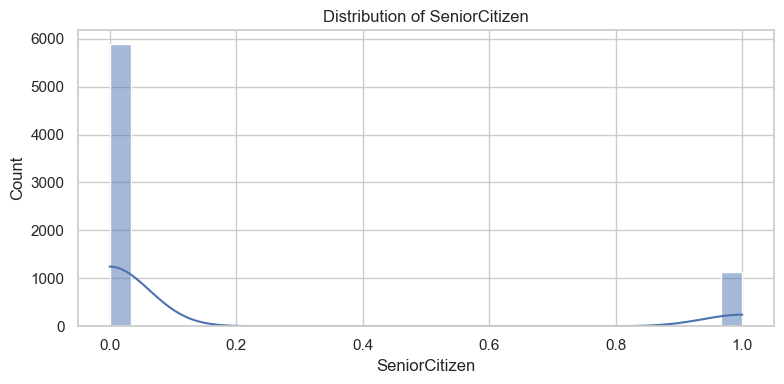

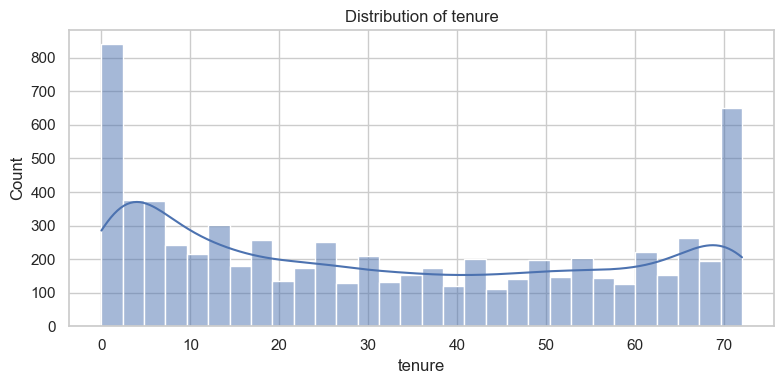

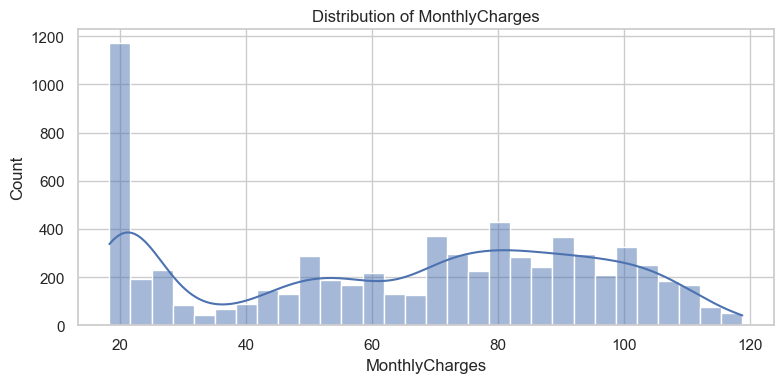

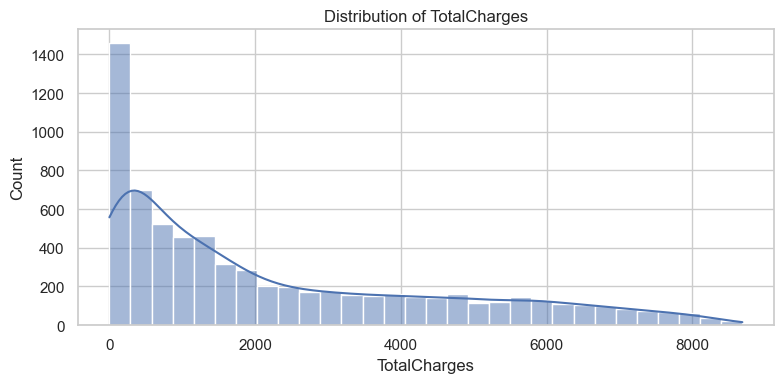

In [17]:
# ============================================================
# Distribution of Numerical Features
# ============================================================

for feature in numerical_features:

    plt.figure(figsize=(8,4))

    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {feature}")

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / f"{feature.lower()}_distribution.png",
        dpi=300
    )

    plt.show()

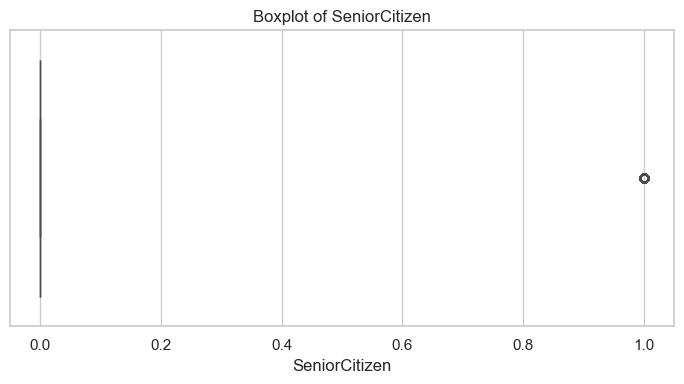

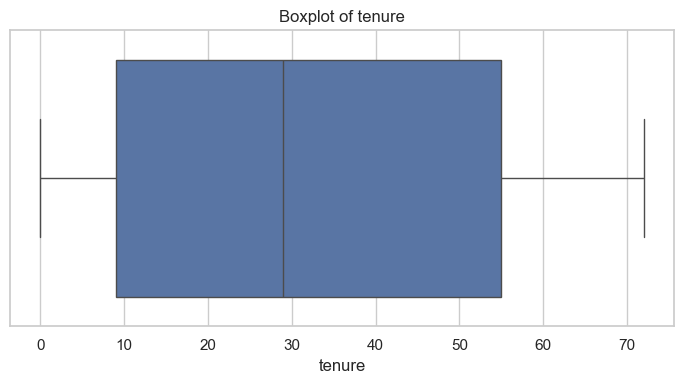

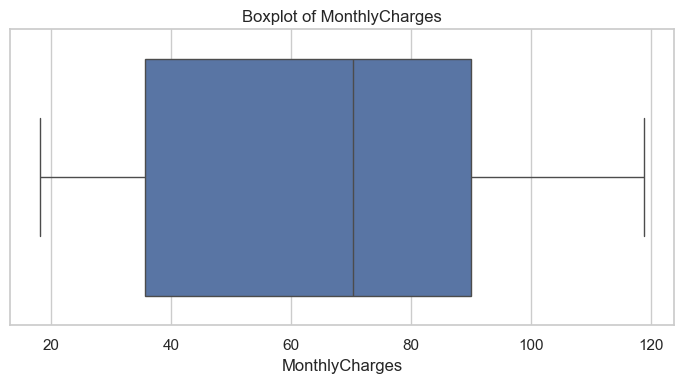

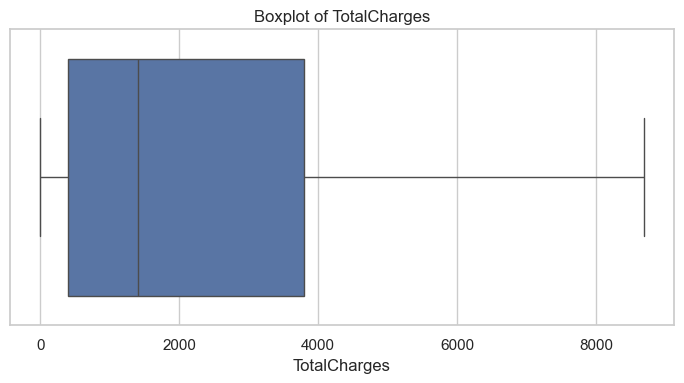

In [18]:
# ============================================================
# Boxplots
# ============================================================

for feature in numerical_features:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        data=df,
        x=feature
    )

    plt.title(f"Boxplot of {feature}")

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / f"{feature.lower()}_boxplot.png",
        dpi=300
    )

    plt.show()

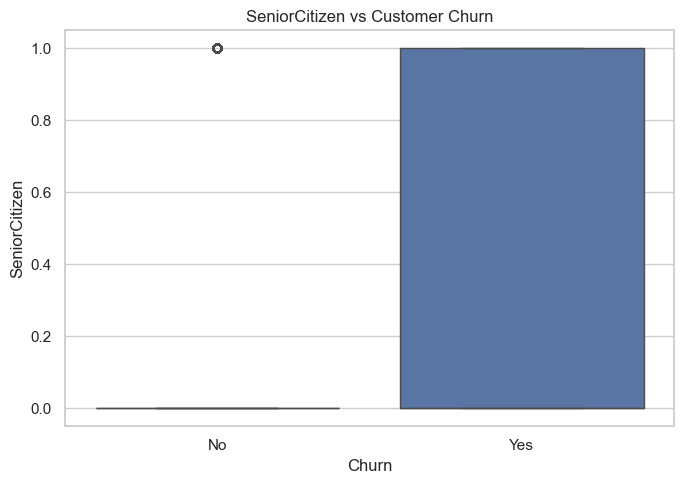

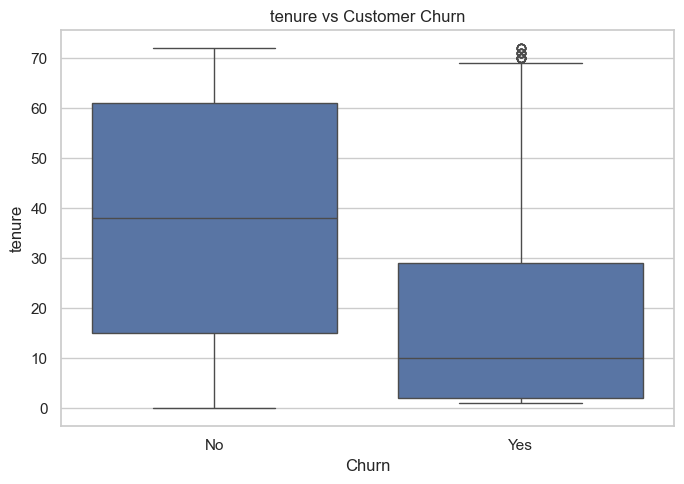

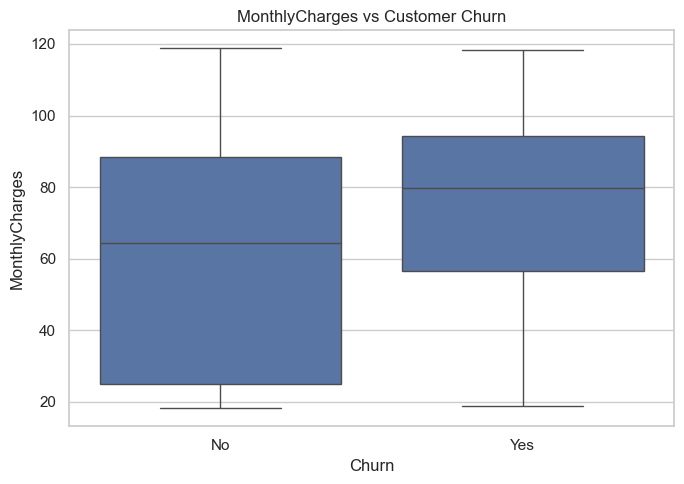

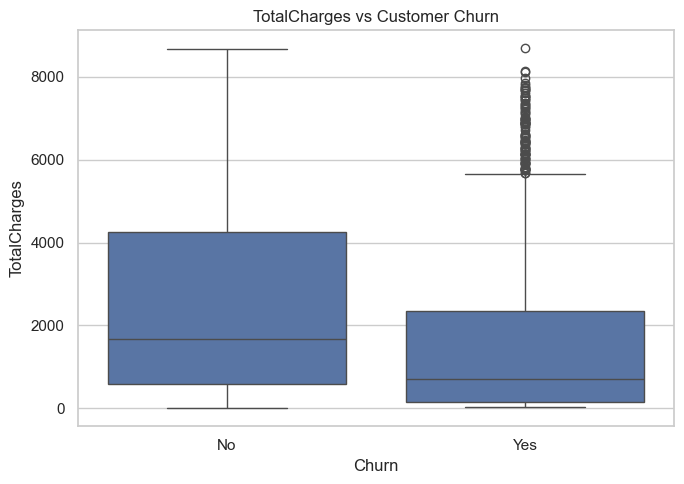

In [19]:
# ============================================================
# Numerical Features vs Churn
# ============================================================

for feature in numerical_features:

    plt.figure(figsize=(7,5))

    sns.boxplot(
        data=df,
        x="Churn",
        y=feature
    )

    plt.title(f"{feature} vs Customer Churn")

    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / f"{feature.lower()}_vs_churn.png",
        dpi=300
    )

    plt.show()

In [20]:
# ============================================================
# Numerical Feature Summary by Churn
# ============================================================

for feature in numerical_features:

    print("=" * 70)
    print(feature.upper())
    print("=" * 70)

    display(
        df.groupby("Churn")[feature]
        .describe()
        .round(2)
    )

SENIORCITIZEN


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5164.0,0.13,0.34,0.0,0.0,0.0,0.0,1.0
Yes,1857.0,0.26,0.44,0.0,0.0,0.0,1.0,1.0


TENURE


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5164.0,37.64,24.08,0.0,15.0,38.0,61.0,72.0
Yes,1857.0,18.09,19.55,1.0,2.0,10.0,29.0,72.0


MONTHLYCHARGES


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5164.0,61.34,31.07,18.25,25.1,64.5,88.46,118.75
Yes,1857.0,74.60,24.60,18.85,56.5,79.7,94.25,118.35


TOTALCHARGES


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5164.0,2554.81,2329.55,0.00,577.1,1683.0,4264.06,8672.45
Yes,1857.0,1541.38,1893.15,18.85,140.7,713.1,2345.20,8684.80


In [21]:
# ============================================================
# Numerical Feature Insights
# ============================================================

print("=" * 70)
print("BUSINESS INSIGHTS")
print("=" * 70)

avg_tenure = df.groupby("Churn")["tenure"].mean()
avg_monthly = df.groupby("Churn")["MonthlyCharges"].mean()
avg_total = df.groupby("Churn")["TotalCharges"].mean()

print(f"""
Average Tenure
--------------
Stayed  : {avg_tenure['No']:.2f} months
Churned : {avg_tenure['Yes']:.2f} months

Average Monthly Charges
-----------------------
Stayed  : ${avg_monthly['No']:.2f}
Churned : ${avg_monthly['Yes']:.2f}

Average Total Charges
---------------------
Stayed  : ${avg_total['No']:.2f}
Churned : ${avg_total['Yes']:.2f}
""")

print("Key Observations:")
print("• Customers with lower tenure are more likely to churn.")
print("• Churned customers generally have higher monthly charges.")
print("• Customers with higher total charges are usually long-term customers and tend to stay.")

BUSINESS INSIGHTS

Average Tenure
--------------
Stayed  : 37.64 months
Churned : 18.09 months

Average Monthly Charges
-----------------------
Stayed  : $61.34
Churned : $74.60

Average Total Charges
---------------------
Stayed  : $2554.81
Churned : $1541.38

Key Observations:
• Customers with lower tenure are more likely to churn.
• Churned customers generally have higher monthly charges.
• Customers with higher total charges are usually long-term customers and tend to stay.


In [22]:
# ============================================================
# Categorical Features
# ============================================================

categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

# Treat SeniorCitizen as categorical
categorical_features.append("SeniorCitizen")

# Remove target variable
categorical_features.remove("Churn")

print("=" * 70)
print("CATEGORICAL FEATURES")
print("=" * 70)

print(f"Total Categorical Features : {len(categorical_features)}")

categorical_features

CATEGORICAL FEATURES
Total Categorical Features : 17


['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'SeniorCitizen']

In [23]:
# ============================================================
# Unique Values in Categorical Features
# ============================================================

for feature in categorical_features:

    print("=" * 60)
    print(feature.upper())
    print("=" * 60)

    display(df[feature].value_counts())

CUSTOMERID


customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
             ..
9959-WOFKT    1
8191-XWSZG    1
3655-SNQYZ    1
5129-JLPIS    1
0280-XJGEX    1
Name: count, Length: 7021, dtype: int64

GENDER


gender
Male      3541
Female    3480
Name: count, dtype: int64

PARTNER


...

PaperlessBilling
Yes    4161
No     2860
Name: count, dtype: int64

PAYMENTMETHOD


PaymentMethod
Electronic check             2359
Mailed check                 1596
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

SENIORCITIZEN


SeniorCitizen
0    5880
1    1141
Name: count, dtype: int64

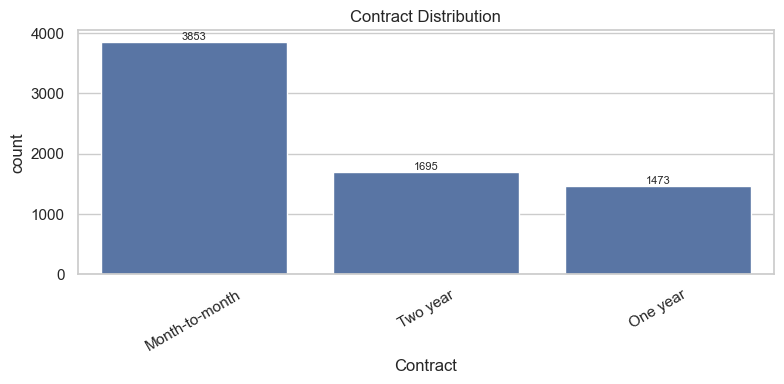

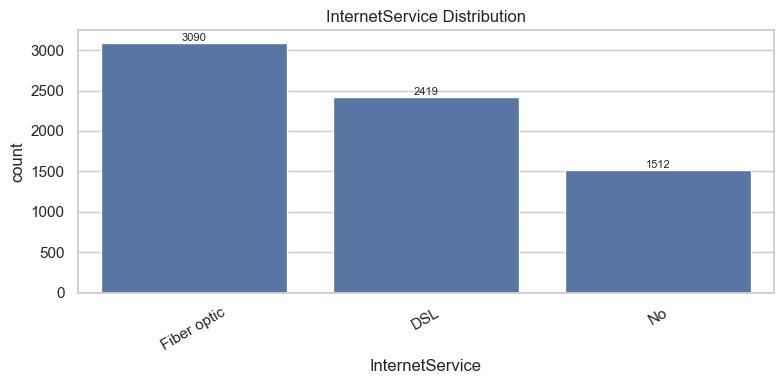

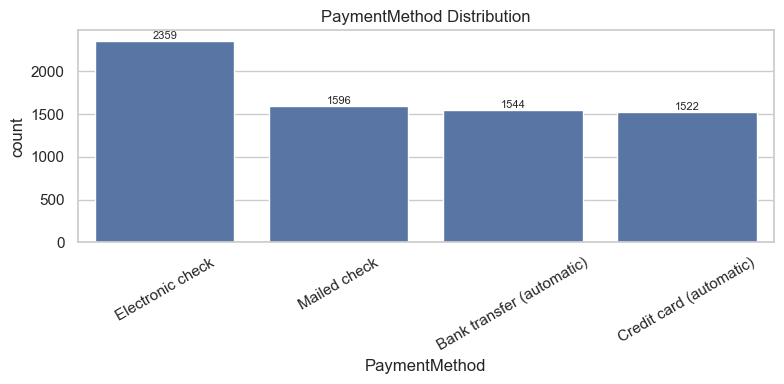

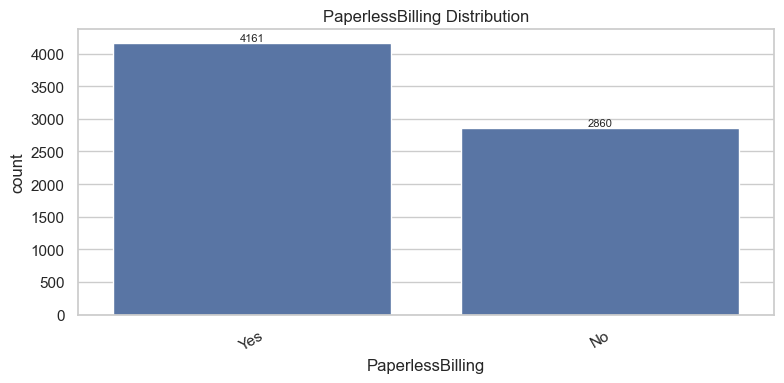

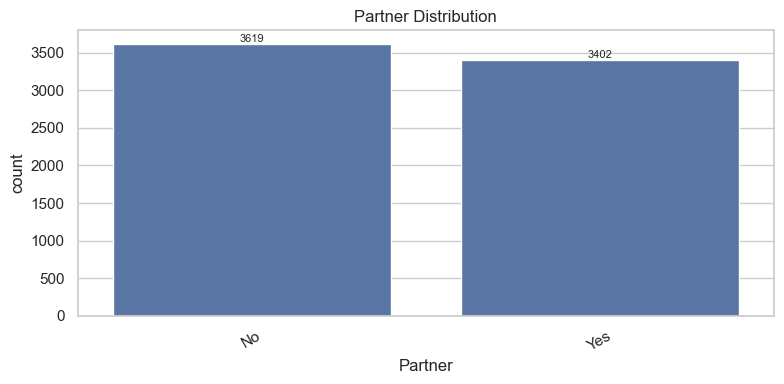

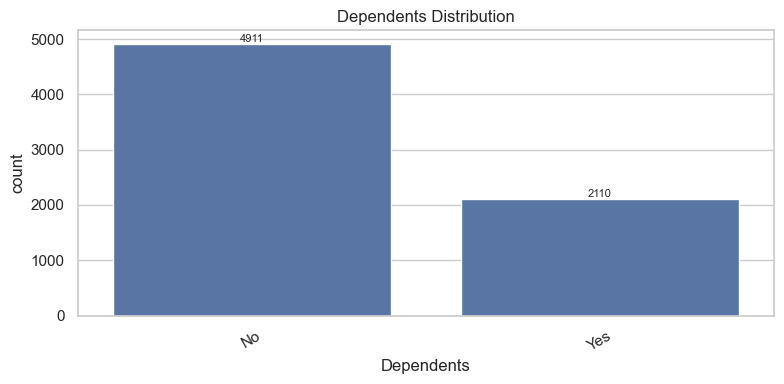

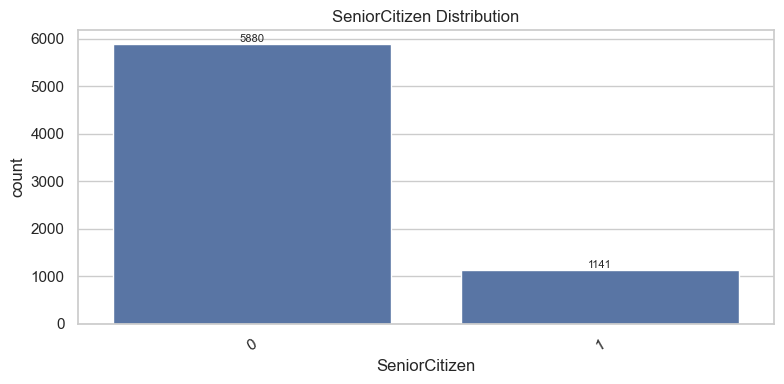

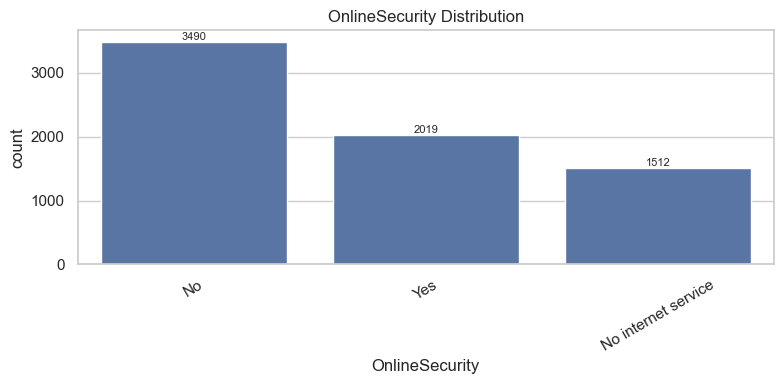

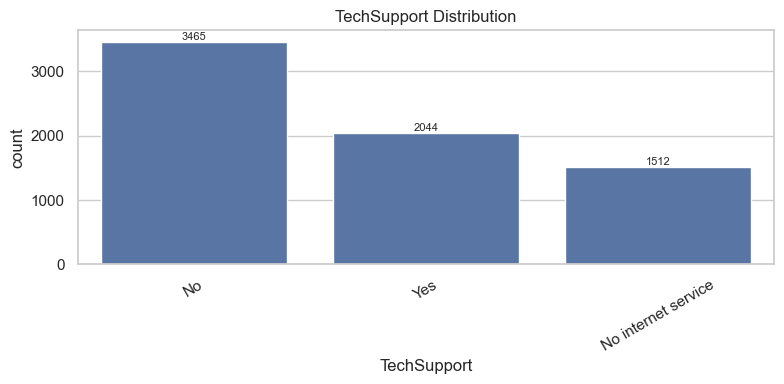

In [24]:
# ============================================================
# Frequency Distribution (Important Features Only)
# ============================================================

important_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "PaperlessBilling",
    "Partner",
    "Dependents",
    "SeniorCitizen",
    "OnlineSecurity",
    "TechSupport"
]

for feature in important_features:

    plt.figure(figsize=(8, 4))

    ax = sns.countplot(
        data=df,
        x=feature,
        order=df[feature].value_counts().index
    )

    for container in ax.containers:
        ax.bar_label(container, fontsize=8)

    plt.xticks(rotation=30)
    plt.title(f"{feature} Distribution")

    plt.tight_layout()
    plt.show()
    plt.close()

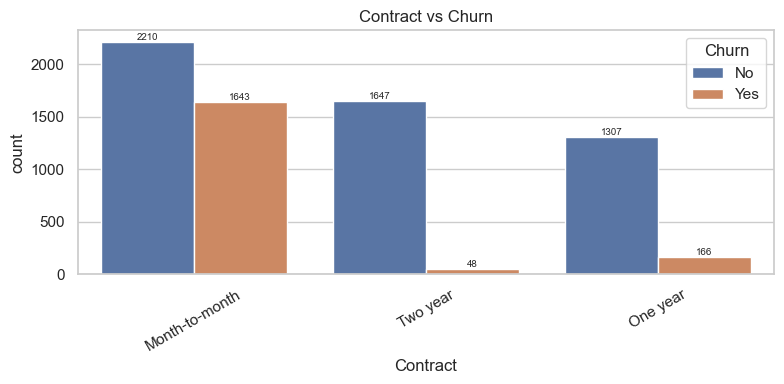

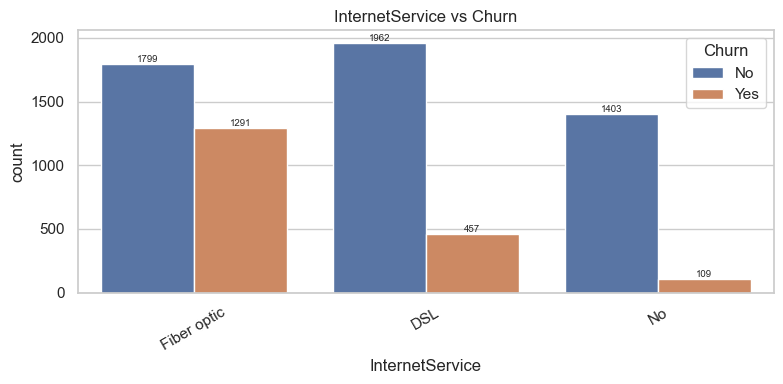

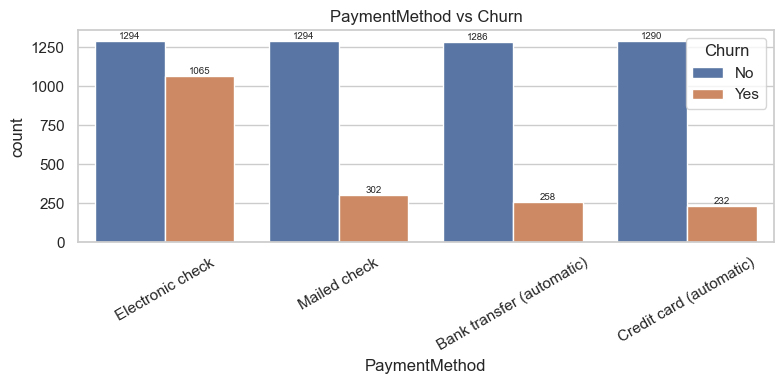

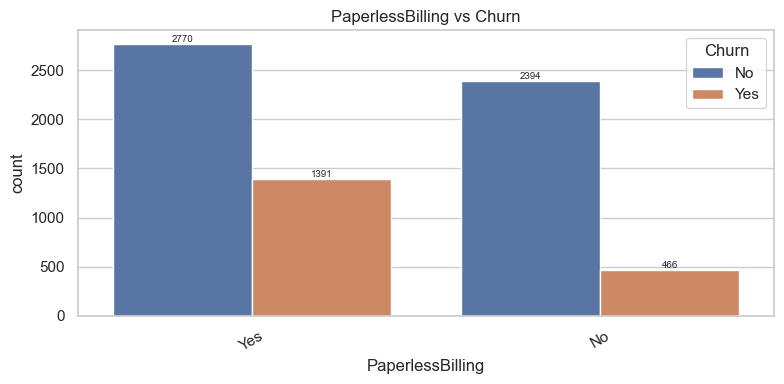

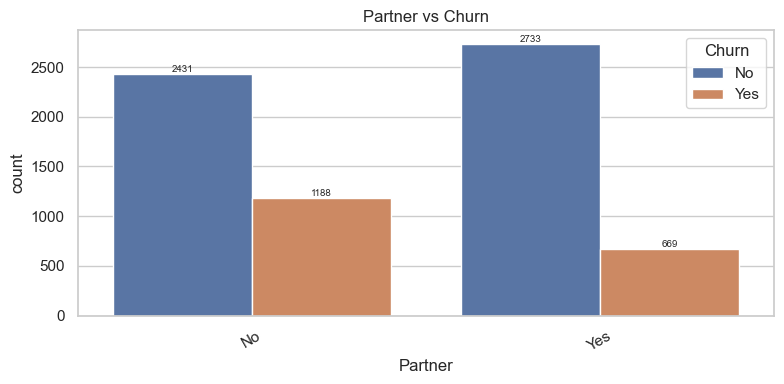

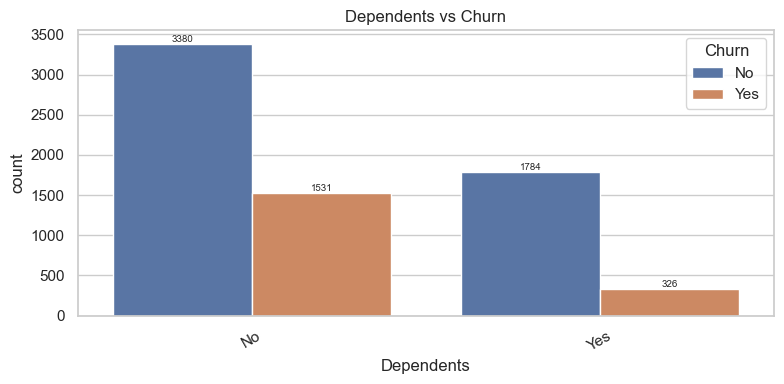

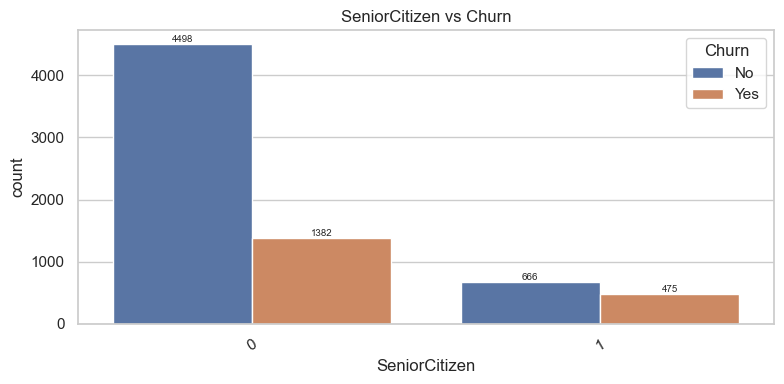

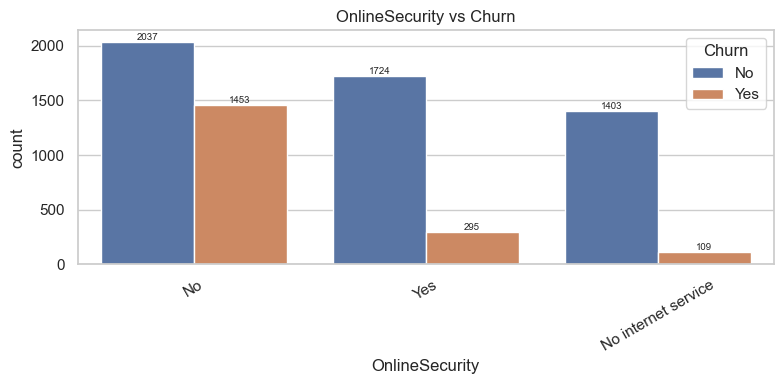

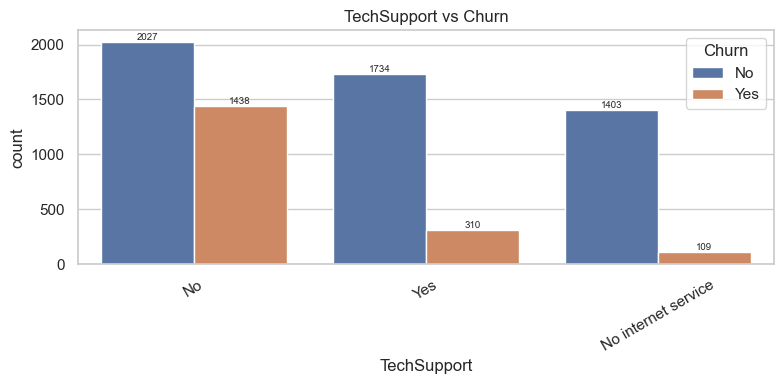

In [25]:
# ============================================================
# Important Categorical Features vs Churn
# ============================================================

important_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "PaperlessBilling",
    "Partner",
    "Dependents",
    "SeniorCitizen",
    "OnlineSecurity",
    "TechSupport"
]

for feature in important_features:

    plt.figure(figsize=(8, 4))

    ax = sns.countplot(
        data=df,
        x=feature,
        hue="Churn",
        order=df[feature].value_counts().index
    )

    for container in ax.containers:
        ax.bar_label(container, fontsize=7)

    plt.xticks(rotation=30)
    plt.title(f"{feature} vs Churn")
    plt.tight_layout()

    plt.show()
    plt.close()

In [26]:
# ============================================================
# Churn Percentage by Category
# ============================================================

for feature in categorical_features:

    churn_rate = (
        pd.crosstab(
            df[feature],
            df["Churn"],
            normalize="index"
        ) * 100
    )

    print("=" * 70)
    print(feature.upper())
    print("=" * 70)

    display(churn_rate.round(2))

CUSTOMERID


Churn,No,Yes
customerID,,
0002-ORFBO,100.0,0.0
0003-MKNFE,100.0,0.0
0004-TLHLJ,0.0,100.0
0011-IGKFF,0.0,100.0
0013-EXCHZ,0.0,100.0
...,...,...
9987-LUTYD,100.0,0.0
9992-RRAMN,0.0,100.0
9992-UJOEL,100.0,0.0


GENDER


Churn,No,Yes
gender,,
Female,73.16,26.84
Male,73.93,26.07


PARTNER


...

Churn,No,Yes
PaperlessBilling,,
No,83.71,16.29
Yes,66.57,33.43


PAYMENTMETHOD


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.85,45.15
Mailed check,81.08,18.92


SENIORCITIZEN


Churn,No,Yes
SeniorCitizen,,
0,76.50,23.50
1,58.37,41.63


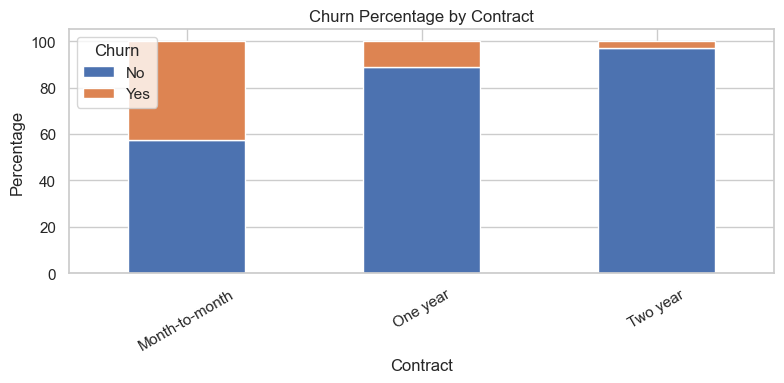

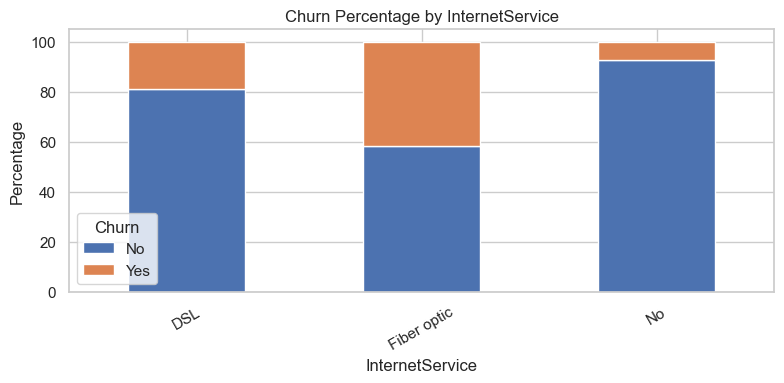

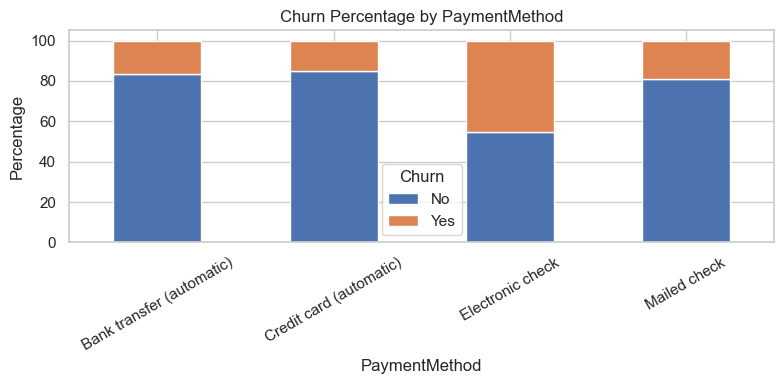

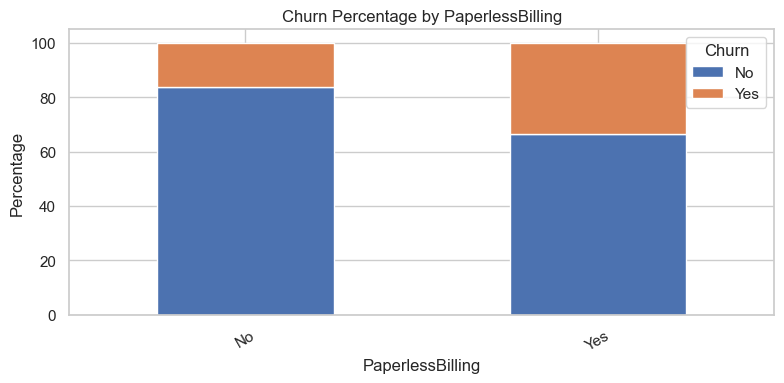

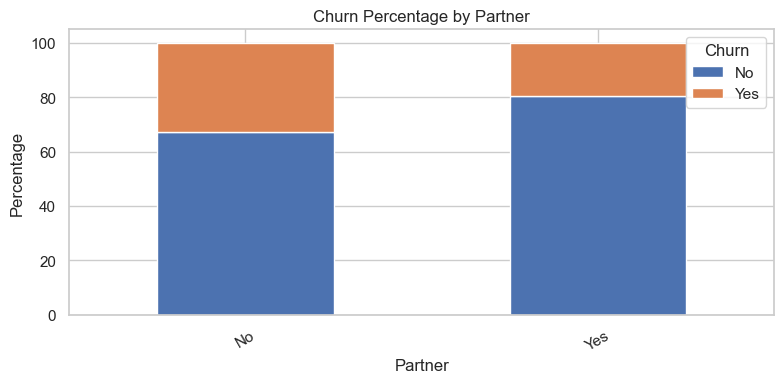

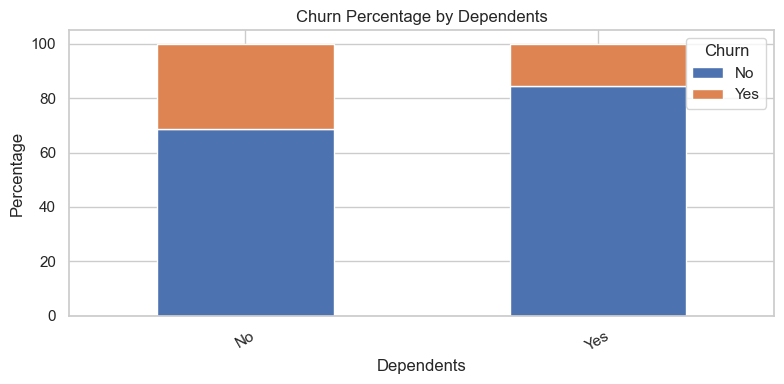

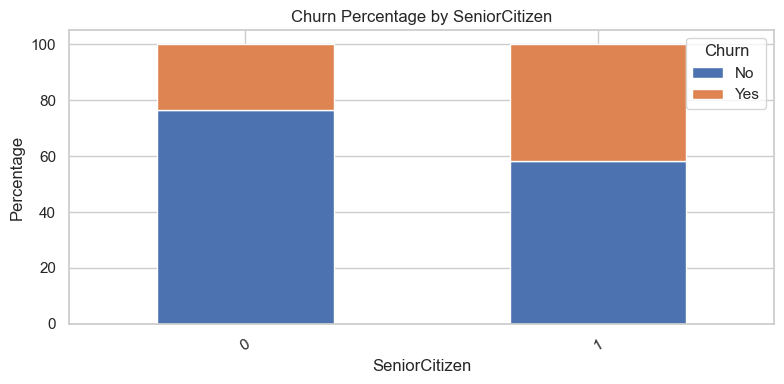

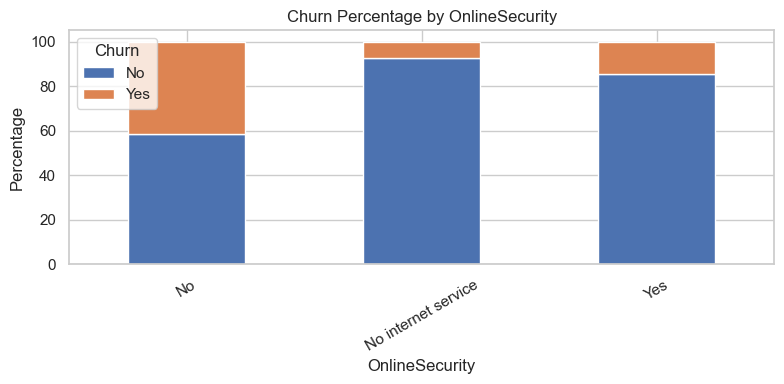

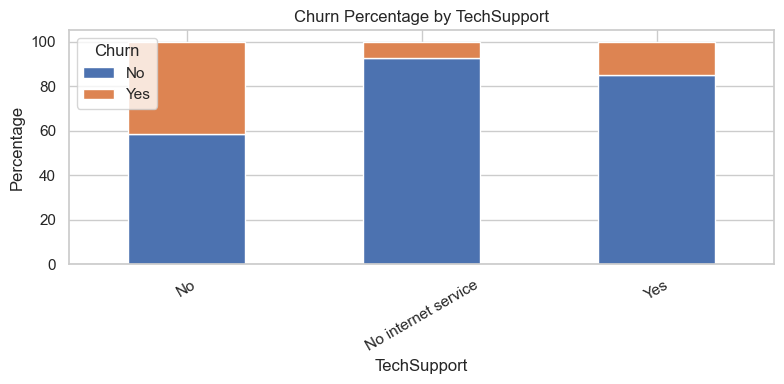

In [27]:
# ============================================================
# Stacked Churn Percentage (Important Features Only)
# ============================================================

important_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "PaperlessBilling",
    "Partner",
    "Dependents",
    "SeniorCitizen",
    "OnlineSecurity",
    "TechSupport"
]

for feature in important_features:

    churn_rate = (
        pd.crosstab(
            df[feature],
            df["Churn"],
            normalize="index"
        ) * 100
    )

    ax = churn_rate.plot(
        kind="bar",
        stacked=True,
        figsize=(8, 4)
    )

    plt.title(f"Churn Percentage by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Percentage")
    plt.xticks(rotation=30)
    plt.legend(title="Churn")

    plt.tight_layout()
    plt.show()
    plt.close()

In [28]:
# ============================================================
# Business Insights
# ============================================================

print("=" * 70)
print("KEY BUSINESS INSIGHTS")
print("=" * 70)

print("""
Expected patterns to verify:

✓ Month-to-month contracts have the highest churn.

✓ Customers without OnlineSecurity are more likely to churn.

✓ Customers without TechSupport tend to churn more.

✓ Fiber Optic customers generally churn more than DSL users.

✓ Electronic Check users exhibit the highest churn.

✓ Customers using Paperless Billing churn more frequently.

✓ Customers with longer-term contracts (One year / Two year)
  are significantly more loyal.
""")

KEY BUSINESS INSIGHTS

Expected patterns to verify:

✓ Month-to-month contracts have the highest churn.

✓ Customers without OnlineSecurity are more likely to churn.

✓ Customers without TechSupport tend to churn more.

✓ Fiber Optic customers generally churn more than DSL users.

✓ Electronic Check users exhibit the highest churn.

✓ Customers using Paperless Billing churn more frequently.

✓ Customers with longer-term contracts (One year / Two year)
  are significantly more loyal.



In [29]:
# ============================================================
# Correlation Matrix - Numerical Features
# ============================================================

corr_matrix = df[numerical_features].corr(numeric_only=True)

display(corr_matrix.round(3))

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000,0.015,0.219,0.102
tenure,0.015,1.000,0.245,0.826
MonthlyCharges,0.219,0.245,1.000,0.651
TotalCharges,0.102,0.826,0.651,1.000


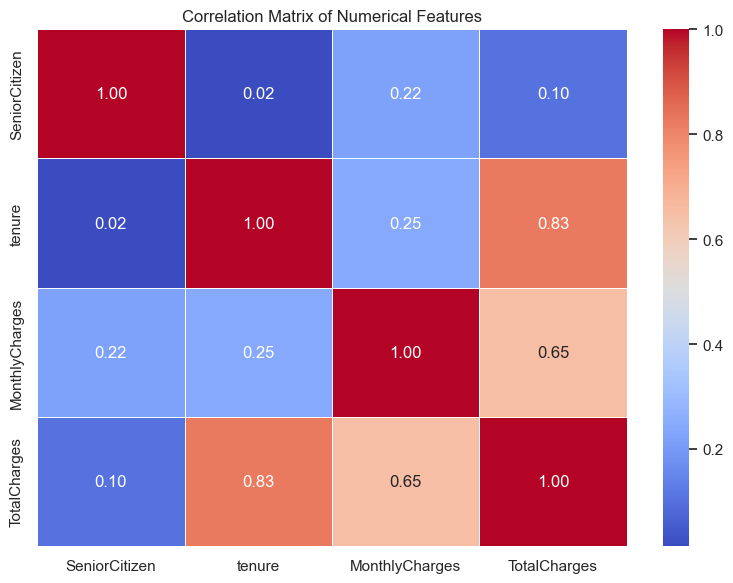

In [30]:
# ============================================================
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()
plt.close()

In [31]:
# ============================================================
# Correlation with Target Variable
# ============================================================

df_corr = df.copy()

df_corr["Churn"] = df_corr["Churn"].map({
    "No": 0,
    "Yes": 1
})

correlation = (
    df_corr[numerical_features + ["Churn"]]
    .corr()["Churn"]
    .drop("Churn")
    .sort_values(key=abs, ascending=False)
)

display(correlation.to_frame("Correlation"))

,Correlation
tenure,-0.351508
TotalCharges,-0.197198
MonthlyCharges,0.194508
SeniorCitizen,0.151619


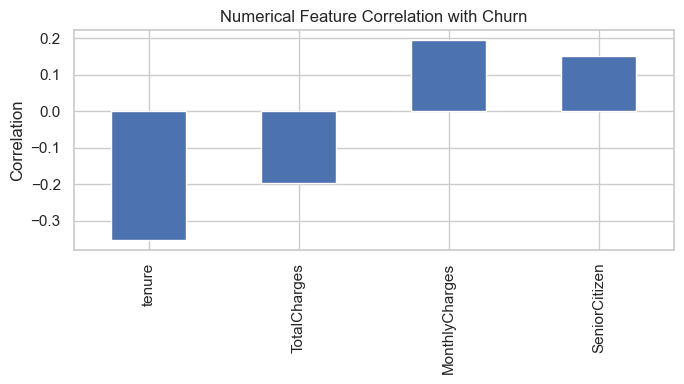

In [32]:
# ============================================================
# Feature Correlation with Churn
# ============================================================

plt.figure(figsize=(7,4))

correlation.plot(kind="bar")

plt.title("Numerical Feature Correlation with Churn")
plt.ylabel("Correlation")

plt.tight_layout()
plt.show()
plt.close()

In [33]:
from scipy.stats import chi2_contingency
# ============================================================
# Chi-Square Test
# ============================================================

chi_results = []

for feature in important_features:

    contingency = pd.crosstab(
        df[feature],
        df["Churn"]
    )

    chi2, p_value, dof, expected = chi2_contingency(contingency)

    chi_results.append({
        "Feature": feature,
        "Chi2": round(chi2, 2),
        "P-value": p_value
    })

chi_df = (
    pd.DataFrame(chi_results)
      .sort_values("Chi2", ascending=False)
)

display(chi_df)

,Feature,Chi2,P-value
0,Contract,1179.80,6.442285e-257
7,OnlineSecurity,846.78,1.329227e-184
8,TechSupport,825.00,7.146858e-180
1,InternetService,732.06,1.085779e-159
2,PaymentMethod,643.92,3.026775e-139
3,PaperlessBilling,254.96,2.151898e-57
5,Dependents,186.79,1.599568e-42
6,SeniorCitizen,160.47,8.934159e-37
4,Partner,155.48,1.099962e-35


In [34]:
# ============================================================
# Statistically Significant Features
# ============================================================

significant = chi_df[chi_df["P-value"] < 0.05]

display(significant)

,Feature,Chi2,P-value
0,Contract,1179.80,6.442285e-257
7,OnlineSecurity,846.78,1.329227e-184
8,TechSupport,825.00,7.146858e-180
1,InternetService,732.06,1.085779e-159
2,PaymentMethod,643.92,3.026775e-139
3,PaperlessBilling,254.96,2.151898e-57
5,Dependents,186.79,1.599568e-42
6,SeniorCitizen,160.47,8.934159e-37
4,Partner,155.48,1.099962e-35


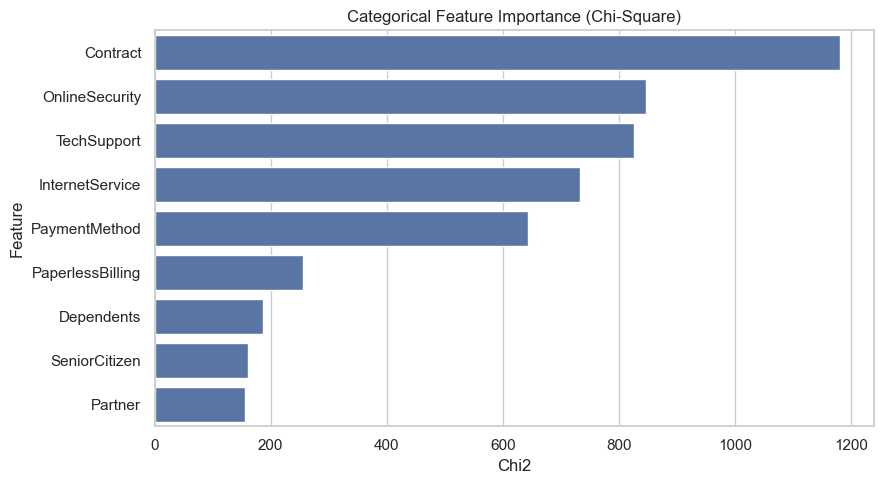

In [35]:
# ============================================================
# Chi-Square Ranking
# ============================================================

plt.figure(figsize=(9,5))

sns.barplot(
    data=chi_df,
    x="Chi2",
    y="Feature"
)

plt.title("Categorical Feature Importance (Chi-Square)")

plt.tight_layout()
plt.show()
plt.close()

In [36]:
# ============================================================
# Final EDA Summary
# ============================================================

print("=" * 70)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("=" * 70)

print("""
Dataset Overview
----------------
✓ Dataset contains clean customer records with no missing values.

Target Variable
---------------
print(f"✓ Churn Rate: {target_percentage['Yes']:.2f}%")
✓ Moderate class imbalance observed.

Numerical Features
------------------
✓ Customers with shorter tenure churn more frequently.
✓ Higher monthly charges are associated with increased churn.
✓ Total charges are higher for retained customers due to longer tenure.

Categorical Features
--------------------
✓ Month-to-month contracts show the highest churn.
✓ Electronic Check customers churn the most.
✓ Fiber Optic users exhibit higher churn.
✓ Lack of OnlineSecurity and TechSupport is associated with higher churn.
✓ Paperless Billing customers tend to churn more.

Statistical Analysis
--------------------
✓ Correlation analysis completed.
✓ Chi-Square test identified statistically significant categorical features.

Next Step
---------
Notebook 03: Data Cleaning & Feature Engineering
""")

EXPLORATORY DATA ANALYSIS SUMMARY

Dataset Overview
----------------
✓ Dataset contains clean customer records with no missing values.

Target Variable
---------------
print(f"✓ Churn Rate: {target_percentage['Yes']:.2f}%")
✓ Moderate class imbalance observed.

Numerical Features
------------------
✓ Customers with shorter tenure churn more frequently.
✓ Higher monthly charges are associated with increased churn.
✓ Total charges are higher for retained customers due to longer tenure.

Categorical Features
--------------------
✓ Month-to-month contracts show the highest churn.
✓ Electronic Check customers churn the most.
✓ Fiber Optic users exhibit higher churn.
✓ Lack of OnlineSecurity and TechSupport is associated with higher churn.
✓ Paperless Billing customers tend to churn more.

Statistical Analysis
--------------------
✓ Correlation analysis completed.
✓ Chi-Square test identified statistically significant categorical features.

Next Step
---------
Notebook 03: Data Cleaning & Fe

In [37]:
# ============================================================
# Save EDA Artifacts and Cleaned Interim Dataset
# ============================================================

corr_matrix.to_csv(ARTIFACTS_DIR / "correlation_matrix.csv")
chi_df.to_csv(ARTIFACTS_DIR / "chi_square_results.csv", index=False)

# Save cleaned interim dataset back (with type corrections and no duplicate records)
df.to_csv(ML_INTERIM_DATA, index=False)

print("EDA artifacts and cleaned dataset saved successfully.")

EDA artifacts and cleaned dataset saved successfully.
